In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Updated Cloud Cost.csv")

# Show data
print(df.head())

  server_id  cpu_usage  memory_usage  hours_running server_type  \
0        S1         94            43              8       large   
1        S2         52            36             12       small   
2        S3         18            27             16      medium   
3        S4         56            40             16      medium   
4        S5         84            79              8       small   

   cost_per_hour  Daily Cost  Status  
0             20         160  Active  
1              5          60  Active  
2             10         160    Idle  
3             10         160  Active  
4              5          40  Active  


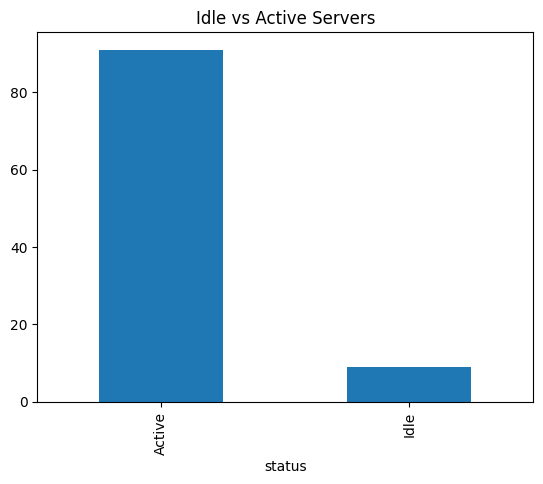

In [ ]:
df['status'].value_counts().plot(kind='bar')
plt.title("Idle vs Active Servers")
plt.show()

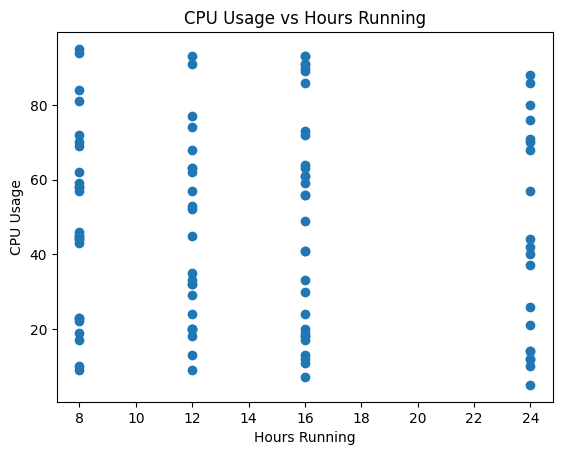

In [ ]:
plt.scatter(df['hours_running'], df['cpu_usage'])
plt.title("CPU Usage vs Hours Running")
plt.xlabel("Hours Running")
plt.ylabel("CPU Usage")
plt.show()

In [ ]:
df['daily_cost'] = df['hours_running'] * df['cost_per_hour']

In [ ]:
df['status'] = df.apply(lambda x: 'Idle' if x['cpu_usage'] < 20 and x['memory_usage'] < 30 else 'Active', axis=1)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = df[['hours_running']]
y = df['cpu_usage']

model.fit(X, y)

df['predicted_cpu'] = model.predict(X)

In [ ]:
def recommend(row):
    if row['status'] == 'Idle':
        return f"Shutdown → Save ₹{row['daily_cost']}"
    else:
        return "Keep Running"

df['recommendation'] = df.apply(recommend, axis=1)

In [ ]:
total_savings = df[df['status'] == 'Idle']['daily_cost'].sum()

print("💰 Total Possible Savings: ₹", total_savings)

💰 Total Possible Savings: ₹ 2720


In [ ]:
df.to_csv("final_cloud_data.csv", index=False)

In [ ]:
df['index'] = range(1, len(df)+1)


In [ ]:
df.to_csv("final_cloud_data.csv", index=False)

In [ ]:
df['server_num'] = df['server_id'].str.extract('(\d+)').astype(int)

df = df.sort_values(by='server_num').reset_index(drop=True)

df['index'] = range(1, len(df) + 1)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_18938/1480915664.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['server_num'] = df['server_id'].str.extract('(\d+)').astype(int)


In [ ]:
df = df.sort_values('cpu_usage').reset_index(drop=True)
df['index'] = range(1, len(df)+1)

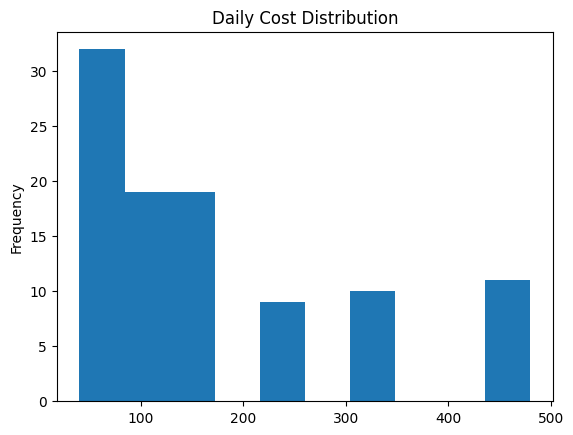

In [ ]:
import matplotlib.pyplot as plt

df['daily_cost'].plot(kind='hist')
plt.title("Daily Cost Distribution")
plt.show()